# PBPK-PD Model Coupling
Here, we present the mechanistically coupled PBPK–PD model for <sup>177</sup>Lu-PSMA radiopharmaceutical therapies. With this model, we provide preliminary model simulations and outputs. This code includes the current .sbml file for the coupled model originally developed using MATLAB SimBiology.

We are actively expanding this notebook to incorporate comprehensive model analyses and additional simulation workflows. A manuscript describing this work is currently in preparation for publication and will include further simulations and analyses representative of those presented at the 2026 SNMMI Annual Meeting.

In [1]:
# Import dependencies
import pycno
import numpy as np
import matplotlib.pyplot as plt

### Setting up the dosing scheme
The model dosing input considers both <sup>177</sup>Lu-labelled and unlabelled PSMA ligand. The ratio between labelled and unlabelled ligand is consistent with Pluvicto measurements from BC Cancer.

In [2]:
n_cycles = 6
cycle_interval_weeks = 6 # weeks between cycles

cycle_interval_min = cycle_interval_weeks * 7 * 24 * 60 # convert to minutes
treatment_times = np.linspace(0, cycle_interval_min * (n_cycles - 1), n_cycles) # treatment times in minutes

print(treatment_times)

[     0.  60480. 120960. 181440. 241920. 302400.]


In [3]:
# Dosing consistent with 177Lu-PSMA-617 (Pluvicto hot-to-cold ratio)
dose_hot = 10.18 # nmol; 7.4 GBq
dose_cold = 46.91 # nmol

dose = pycno.Dose(
    times = treatment_times,
    targets = {
        'Blood.Hot': [dose_hot] * n_cycles,
        'Blood.Cold': [dose_cold] * n_cycles
    })

### Importing and calling the PBPK-PD coupled model

In [4]:
model = pycno.Model(
    model_name='260511_pkpd_coupled.sbml',
    )

In [5]:
observables_compartments = model.get_compartments() # provides a list of all compartments in the model
print(observables_compartments)

observables_parameters = model.get_parameters() # provides a list of all parameters in the model
print(observables_parameters)

['Blood', 'Tumor1', 'Kidney', 'SG', 'TumorRest', 'Rest', 'Tumor1Mass']
[('lambdaPhys', 7.15e-05), ('k_on', 0.046), ('k_off', 0.368), ('F_Tumor1', -1.0), ('PS_Tumor1', -1.0), ('Rden_Tumor1_0', 57.0), ('R0_Tumor1', -1.0), ('lambdaIntern_Tumor1', 0.001), ('lambdaRel_Tumor1', 0.00015), ('F_TumorRest', -1.0), ('PS_TumorRest', -1.0), ('Rden_TumorRest', 266.0), ('R0_TumorRest', 13.0), ('lambdaIntern_TumorRest', 0.001), ('lambdaRel_TumorRest', 0.00015), ('F_SG', -1.0), ('PS_SG', -1.0), ('Rden_SG', 38.0), ('R0_SG', -1.0), ('lambdaIntern_SG', -1.0), ('lambdaRel_SG', 0.00042), ('F_Rest', -1.0), ('PS_Rest', -1.0), ('F_Lungs', -1.0), ('F_Kidney', -1.0), ('TER_Kidney', 0.2), ('Rden_Kidney', 14.0), ('R0_Kidney', -1.0), ('lambdaIntern_Kidney', -1.0), ('lambdaRel_Kidney', 0.00029), ('GFR', -1.0), ('phi', 0.66), ('f_exc', 0.96), ('lambdaIntern_Normal', -1.0), ('lambdaRel_Normal', -1.0), ('bodySurfaceArea', 1.9), ('hematocrit', 0.4), ('bodyHeight', 160.0), ('bodyWeight', 100.0), ('F', -1.0), ('V_p', -1.0

Simulated the time activity curves (TAC) for the primary tumour compartment (tumor 1), kidneys, and salivary glands (SG)

In [6]:
output_compartments = ['Tumor1', 'Kidney', 'SG'] #, 'Kidney', 'SG',  'Rest', 'Blood']
# output_compartments = ['Tumor1Mass'] #, 'Kidney', 'SG',  'Rest', 'Blood']
output_parameters = ['Rden_Tumor1', 'R_Tumor1', 'sValue_multiscale', 'DoseRate_Tumor1'] #, 'sValue_multiscale
time, TACs, parameters = model.simulate(dose=dose,stop=400000, steps=100000,
                            output_compartments=output_compartments,
                            output_parameters=output_parameters
                            )

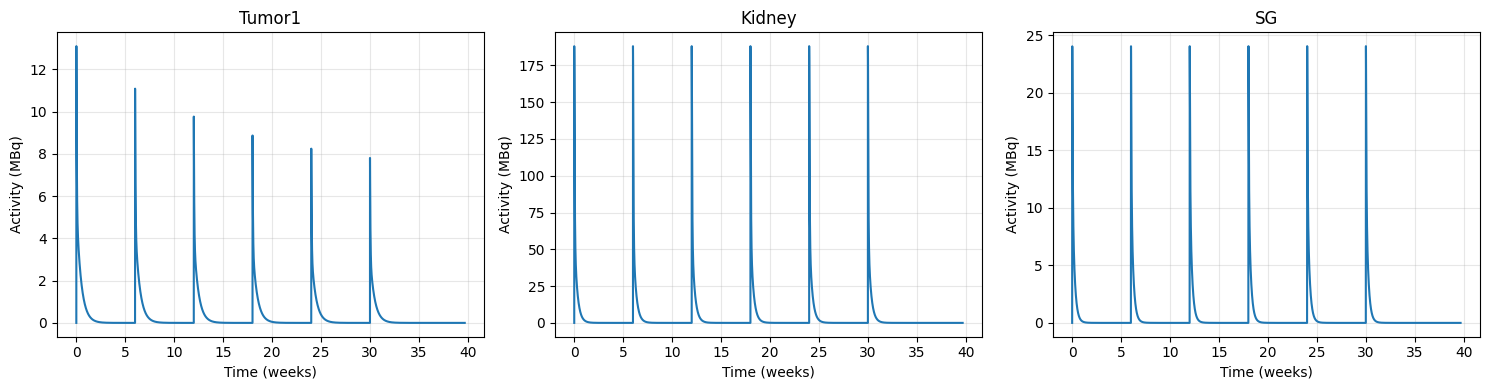

In [7]:
n_compartments = len(model.output_compartments)
time_days = time / (24 * 60)
time_weeks = time / (7 * 24 * 60)
time_hours = time / 60

fig, axes = plt.subplots(1, n_compartments, figsize=(5 * n_compartments, 4))

# Handle case of single compartment (axes won't be array)
if n_compartments == 1:
    axes = [axes]

time_units = [
    (time_hours, 'Time (hours)'),
    (time_days,  'Time (days)'),
    (time_weeks, 'Time (weeks)'),
]

for i, compartment in enumerate(model.output_compartments):
    t, xlabel = time_weeks, 'Time (weeks)' # default to weeks
    for j in range(TACs.shape[0]):          # iterate over individual TAC curves
        axes[i].plot(t, TACs[j, :, i])
    axes[i].set_title(compartment)
    axes[i].set_ylabel('Activity (MBq)')
    axes[i].set_xlabel(xlabel)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Manuscript figures
1) TACs: cycle-dependent changes in tumor TACs given bidirectional feedback between the PBPK and PD models

In [8]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick

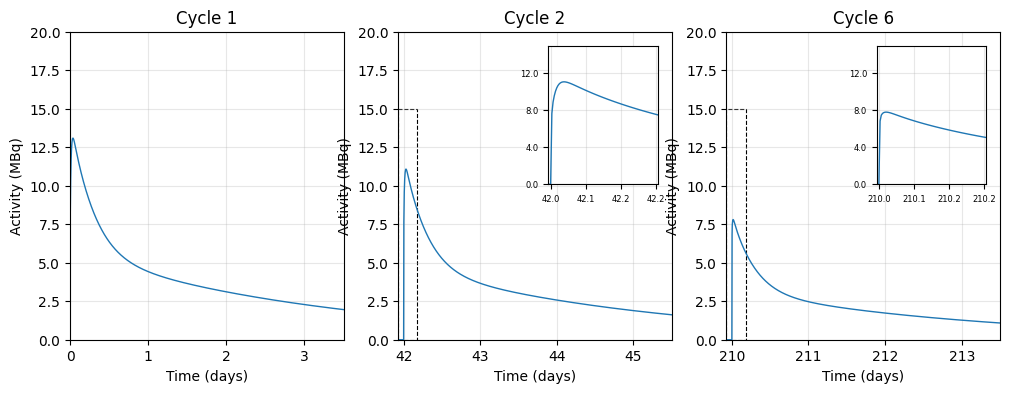

In [9]:
# Defining x-axis limits for each subplot (in days)
xlims = np.array([
    [0, 0.5],
    [6 - 0.01, 6.5],
    [30 - 0.01, 30.5]
]) * 7
ylims = [0, 20]

dose_offset = 0.01 * 7
dose_times = xlims[:, 0] + dose_offset

# Inset settings
add_inset_cycles = [1, 2]   # Apply to Cycle 2 and Cycle 6
inset_duration = 0.25
inset_ylims = [0, 15]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=False)

for k, ax in enumerate(axes):

    ax.plot(time_days, TACs[0,:,0], lw=1)
    ax.grid(True, alpha=0.3)

    ax.set_title(["Cycle 1", "Cycle 2", "Cycle 6"][k])
    ax.set_xlim(xlims[k])
    ax.set_ylim(ylims)
    ax.set_ylabel('Activity (MBq)')
    ax.set_xlabel('Time (days)')

    if k == 0:  # first subplot: integers only
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))

    # --------------------------------------------------
    # Inset (Cycles 2 and 6)
    # --------------------------------------------------
    if k in add_inset_cycles:

        main_start, main_end = xlims[k]
        dose_time = dose_times[k]

        main_width = main_end - main_start
        pre_frac = (dose_time - main_start) / main_width

        inset_pre = inset_duration * pre_frac
        inset_xlim = [
            dose_time - inset_pre,
            dose_time + (inset_duration - inset_pre)
        ]

        # # Compute inset x-limits like MATLAB
        # inset_xlim = [dose_time - inset_pre + 0.035, dose_time + (inset_duration - inset_pre)]

        # Draw rectangle on main axes:
        #   - start at main axis left (xlims[k,0])
        #   - width = diff(inset_xlim)
        #   - height = inset_ylims[1] (vertical in data units)
        rect = Rectangle(
            (xlims[k,0], inset_ylims[0]),       # start at main x-left, bottom of inset y
            inset_xlim[1] - inset_xlim[0],      # width = inset width
            inset_ylims[1] - inset_ylims[0],    # height = inset height
            linestyle='--',
            edgecolor='black',
            facecolor='none',
            linewidth=0.8
        )
        ax.add_patch(rect)

        # Create inset axis (top-right)
        axins = inset_axes(
            ax,
            width="40%",
            height="45%",
            loc="upper right",
            borderpad=1
        )

        axins.plot(time_days, TACs[0,:,0], lw=1)
        axins.set_xlim(inset_xlim)
        axins.set_ylim(inset_ylims)

        # axins.axvline(dose_time, linestyle=':', linewidth=0.8)

        # Format inset ticks: single decimals
        axins.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        axins.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        axins.xaxis.set_major_locator(MaxNLocator(nbins=4))
        axins.yaxis.set_major_locator(MaxNLocator(nbins=4))

        axins.tick_params(labelsize=6)
        axins.grid(True, alpha=0.3)

plt.show()

2) Simulating cycle-dependent changes in pharmacodynamic parameters

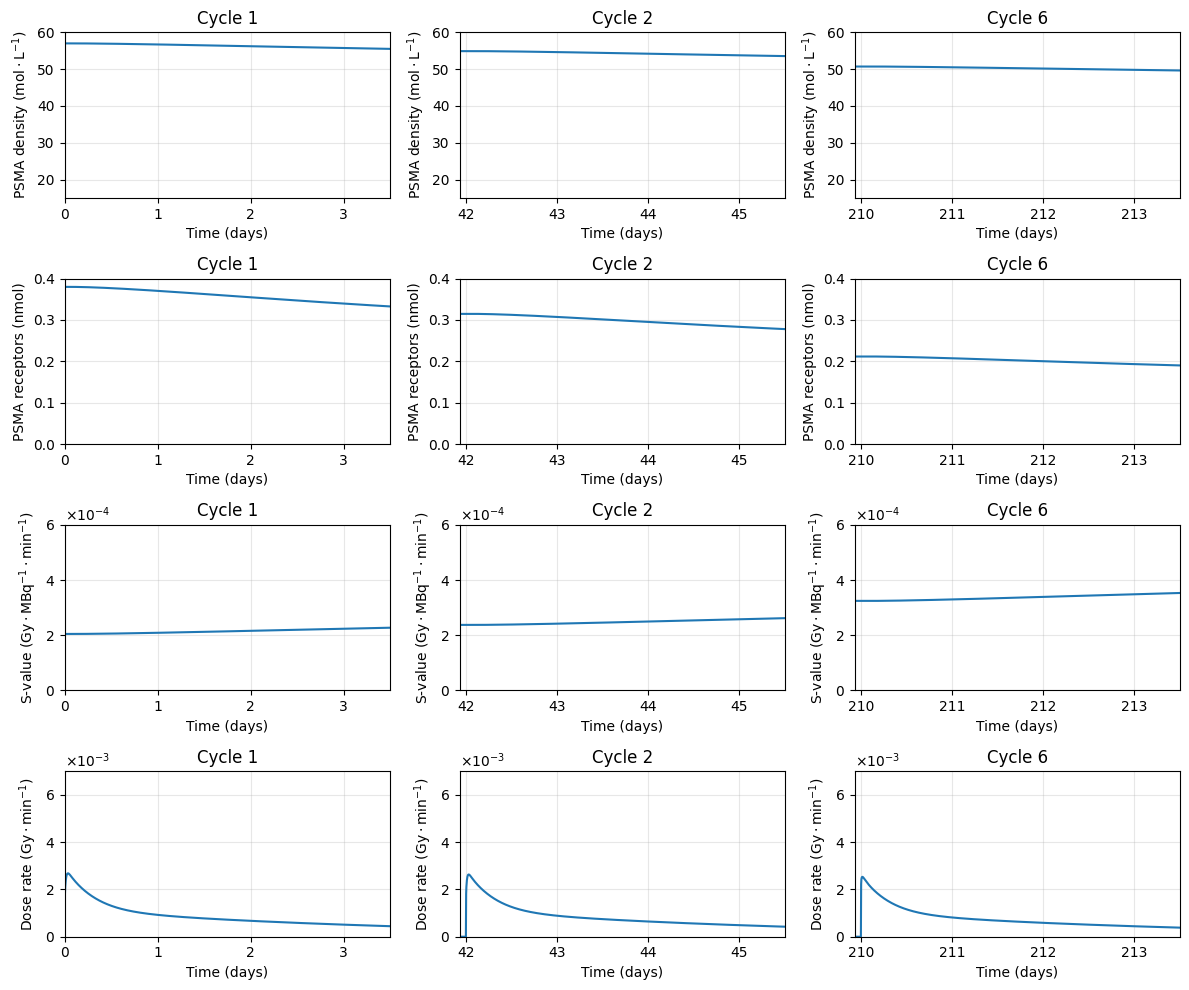

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick

xlims = np.array([
    [0, 0.5],
    [6 - 0.01, 6.5],
    [30 - 0.01, 30.5]
]) * 7

ylims = np.array([
    [15, 60],
    [0, 0.4],
    [0, 6e-4],
    [0, 7e-3]
])

# Y-labels for each row
ylabels = [
    r'PSMA density ($\mathrm{mol \cdot L^{-1}}$)',
    'PSMA receptors (nmol)',
    r'S-value ($\mathrm{Gy \cdot MBq^{-1} \cdot min^{-1}}$)',
    r'Dose rate ($\mathrm{Gy \cdot min^{-1}}$)'
]

# Subplot titles
row0_titles = ["Cycle 1", "Cycle 2", "Cycle 6"]

# Create 4x3 subplots
fig, axes = plt.subplots(4, 3, figsize=(12, 10), sharex=False)

# Loop through rows and columns
for row in range(4):
    for col in range(3):
        ax = axes[row, col]
        # Plot the single parameter for this row
        ax.plot(time_days, parameters[0,:,row])
        ax.grid(True, alpha=0.3)
        ax.set_xlim(xlims[col])
        ax.set_ylim(ylims[row])
        ax.set_ylabel(ylabels[row])
        ax.set_xlabel('Time (days)')
        ax.set_title(row0_titles[col])
        # Force integer day ticks
        ax.xaxis.set_major_locator(MultipleLocator(1))

        # Convert y-ticks to scientific notation for rows 3 and 4
        if row >= 2:  # zero-indexed: row 2 and 3 are 3rd and 4th rows
            formatter = mtick.ScalarFormatter(useMathText=True)
            formatter.set_scientific(True)
            formatter.set_powerlimits((-1,1))  # optional: force exponent style
            ax.yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()